<a href="https://colab.research.google.com/github/yogesh-bhattarai/Django/blob/main/week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml import Pipeline
from pyspark.ml.classification import DecisionTreeClassifier, LogisticRegression, OneVsRest

In [14]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

In [3]:

from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("customer segmentation dataset") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:

import os

os.listdir("/content/drive/MyDrive/dataset")

['property.csv',
 'Airline_Delay_Cause.csv',
 'Diabetes.csv',
 'titanic_synthetic_data.csv',
 'customer_segmentation_dataset.csv']

In [6]:
df = spark.read.csv(
    "/content/drive/MyDrive/dataset/customer_segmentation_dataset.csv",
    header=True,
    inferSchema=True
)

df.show()

+---+-------------+--------------+-----------------+-------------------+----------------+
|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|
+---+-------------+--------------+-----------------+-------------------+----------------+
| 22|       113441|            19|                2|                 44|       Low Value|
| 47|        85415|            74|                7|                 11|    Medium Value|
| 60|        78075|            18|               19|                 37|       Low Value|
| 44|        89388|            84|               10|                 15|      High Value|
| 37|        94910|            85|               15|                 31|      High Value|
| 29|        83134|            64|               12|                  8|    Medium Value|
| 46|        52488|            81|               14|                 39|      High Value|
| 50|        90449|            22|               15|                  8|       Low Value|
| 68|     

In [7]:
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)



In [8]:
print("Total Records :", df.count())

Total Records : 2000000


In [9]:
df.select("customer_segment").distinct().show()

+----------------+
|customer_segment|
+----------------+
|    Medium Value|
|      High Value|
|       Low Value|
+----------------+



In [10]:
segments = df.groupBy("customer_segment").count()
segments.show()

+----------------+-------+
|customer_segment|  count|
+----------------+-------+
|    Medium Value| 505248|
|      High Value| 485871|
|       Low Value|1008881|
+----------------+-------+



In [11]:
print("Total Records:", df.count())

for col in df.columns:
    print(col, df.where(df[col].isNull()).count())

Total Records: 2000000
age 0
annual_income 0
spending_score 0
years_as_customer 0
number_of_purchases 0
customer_segment 0


In [15]:
labelIndexer = StringIndexer(
    inputCol="customer_segment",
    outputCol="label"
)

In [16]:
feature_columns = [
    "age",
    "annual_income",
    "spending_score",
    "years_as_customer",
    "number_of_purchases"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

In [19]:
pipeline = Pipeline(stages=[
    labelIndexer,
    assembler
])

pipelineModel = pipeline.fit(df)

df = pipelineModel.transform(df)

In [20]:
dfSelected = df.select(
    "label",
    "features",
    "customer_segment",
    "age",
    "annual_income",
    "spending_score",
    "years_as_customer",
    "number_of_purchases"
)

dfSelected.show(5)

+-----+--------------------+----------------+---+-------------+--------------+-----------------+-------------------+
|label|            features|customer_segment|age|annual_income|spending_score|years_as_customer|number_of_purchases|
+-----+--------------------+----------------+---+-------------+--------------+-----------------+-------------------+
|  0.0|[22.0,113441.0,19...|       Low Value| 22|       113441|            19|                2|                 44|
|  1.0|[47.0,85415.0,74....|    Medium Value| 47|        85415|            74|                7|                 11|
|  0.0|[60.0,78075.0,18....|       Low Value| 60|        78075|            18|               19|                 37|
|  2.0|[44.0,89388.0,84....|      High Value| 44|        89388|            84|               10|                 15|
|  2.0|[37.0,94910.0,85....|      High Value| 37|        94910|            85|               15|                 31|
+-----+--------------------+----------------+---+-------------+-

In [21]:
train, test = dfSelected.randomSplit([0.7,0.3], seed=2018)

print("Training:",train.count())
print("Testing :",test.count())

Training: 1400225
Testing : 599775


In [24]:
lr = LogisticRegression(
    maxIter=100,
    featuresCol="features",
    labelCol="label"
)

ovr = OneVsRest(
    classifier=lr,
    labelCol="label",
    featuresCol="features"
)

model = ovr.fit(train)

predictions = model.transform(test)

predictions.select(
    "customer_segment",
    "prediction",
    "label"
).show()

+----------------+----------+-----+
|customer_segment|prediction|label|
+----------------+----------+-----+
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
|       Low Value|       0.0|  0.0|
+----------------+----------+-----+
only showing top 20 rows


In [25]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print("Accuracy =",accuracy)

Accuracy = 1.0


In [26]:
f1 = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

print("F1 Score =",f1.evaluate(predictions))

F1 Score = 1.0


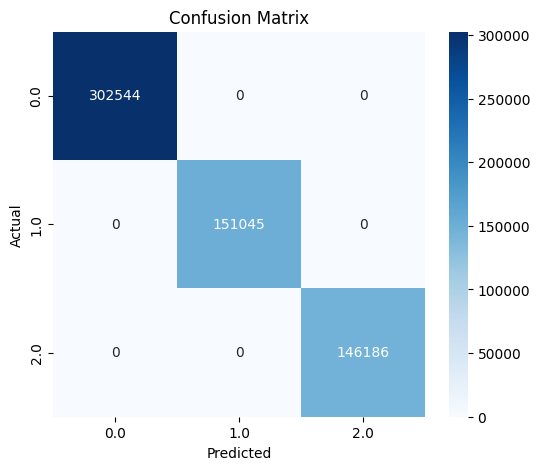

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pred = predictions.select(
    "label",
    "prediction"
).toPandas()

cm = pd.crosstab(
    pred["label"],
    pred["prediction"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,cmap="Blues",fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [28]:
dt = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",
    maxDepth=5
)

dtModel = dt.fit(train)

predictionsDT = dtModel.transform(test)

predictionsDT.select(
    "customer_segment",
    "prediction",
    "probability"
).show()

+----------------+----------+-------------+
|customer_segment|prediction|  probability|
+----------------+----------+-------------+
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.0,0.0,0.0]|
|       Low Value|       0.0|[1.

In [29]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracyDT = evaluator.evaluate(predictionsDT)

print("Decision Tree Accuracy =",accuracyDT)

Decision Tree Accuracy = 0.9697686632487182


In [30]:
f1DT = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

print("Decision Tree F1 =",f1DT.evaluate(predictionsDT))

Decision Tree F1 = 0.9692585488527419


In [31]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=20,
    maxDepth=5
)

rfModel = rf.fit(train)

predRF = rfModel.transform(test)

accuracyRF = evaluator.evaluate(predRF)

print("Random Forest Accuracy =",accuracyRF)

Random Forest Accuracy = 0.9799658205160269
